### Incoherently pumping the THz
The expectation is that now we will be able to observe a peak for the $\Delta_q>0$ side of the spectrum.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.signal import find_peaks

Physical parameters

In [2]:
Omega = 20   # drive del qubit

gamma = 1       #decay en el qubit
kappa_a = 1     #decay en la cavidad del sensor
kappa_b = 1     #decay en la cav de THz

g = 0.001       # acoplo qubit con optico
chi =  1      # acoplo qubit con THz

Na = 2        # truncación de la primera cavidad 
Nb = 20        # segunda cavidad

P = 0.3 * kappa_b #  is this too low/high ? 

Operators

In [3]:
# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)
Dissipators.append(np.sqrt(P) * b_plus)

Preparamos el barrido en valores de $\Delta$

In [4]:
npoints = 40

# valores a probar de w_THz
w_THz_list = np.linspace(10,35,9)

# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)

# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-2*Omega, 2*Omega, npoints)


Hamiltoniano: $$H = \frac{\Omega}{2}\sigma_x + \omega_{THz}b^\dagger b+ \Delta_a a^\dagger a +\Delta_q\sigma_z + g(a^\dagger\sigma_- + a\sigma_+) + \chi(\sigma_z+1)(a + a^\dagger)$$

Cuando la cavidad está muy debilmente acoplada, podemos calcular el espectro como $$S(\omega)\ \alpha\ \braket{a^\dagger a}^{SS}$$.


Donde $$\braket{a^\dagger a}^{SS} = Tr(\rho_{SS}a^\dagger a)$$

In [5]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}

# Doble bucle
for idx, w_b in enumerate(w_THz_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))

    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[w_b] = S_map



### Gráficas de los mapas
Con líneas verticales que marcan el valor de $\omega_{THz}$ y líneas horizontales con el $\Delta_q$ que hemos calculado

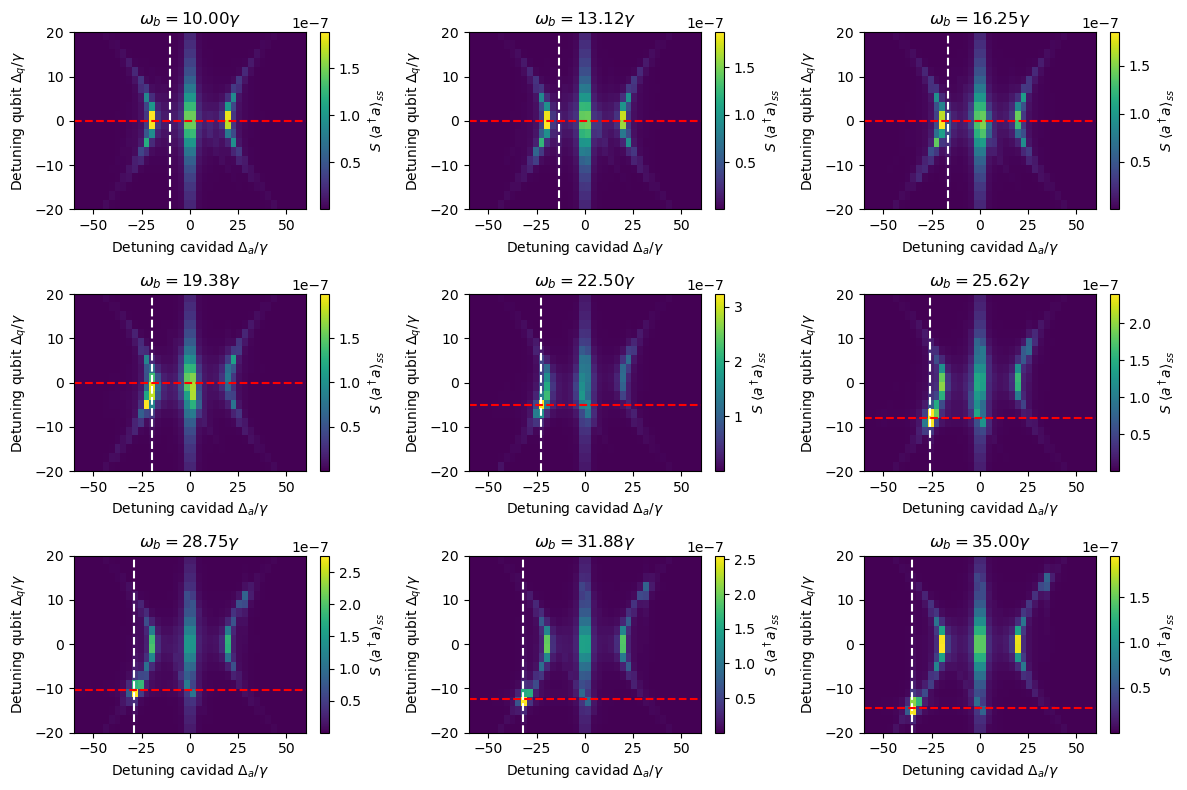

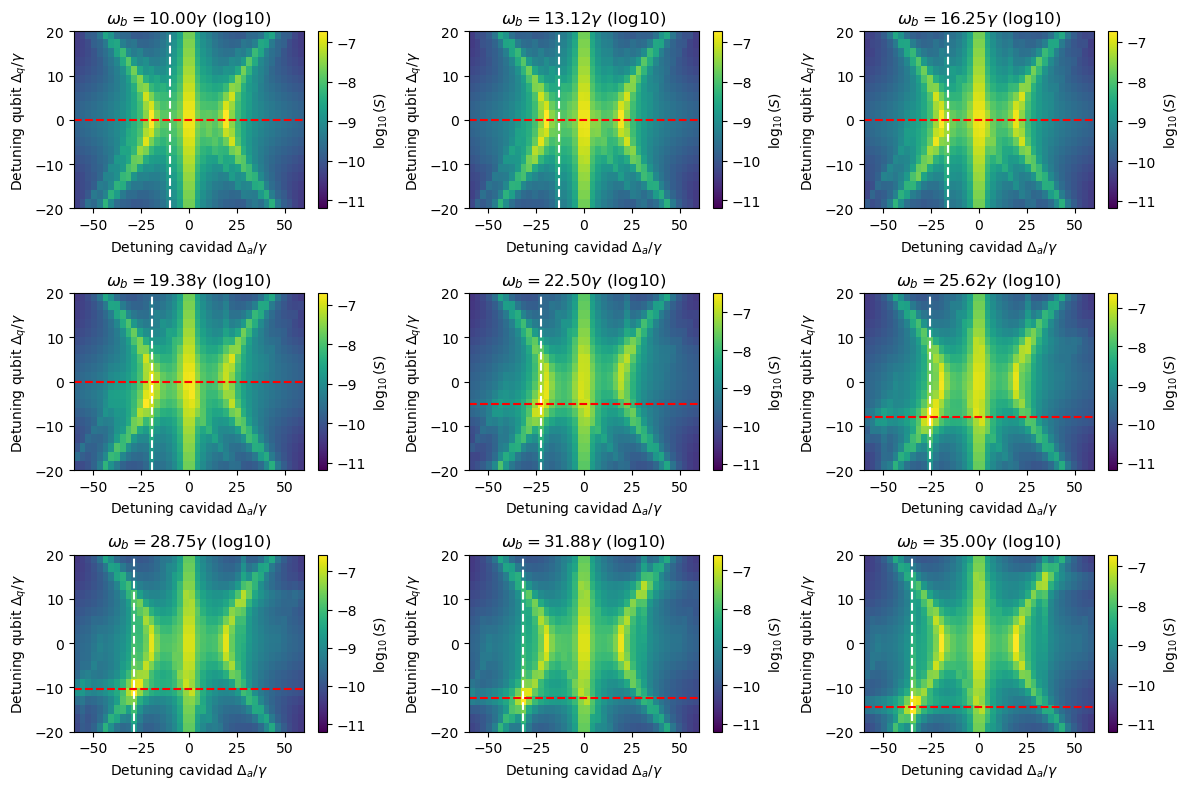

In [6]:
# Crear figuras y ejes
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(3, 3, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, w_b in enumerate(w_THz_list):

    Delta_q = 0
    if w_b > Omega:
        Delta_q = 1/2*np.sqrt(w_b**2 - Omega**2)

    S_map = all_S_maps[w_b]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    ax.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax.set_title(rf"$\omega_b = {w_b:.2f}\gamma$")
    ax.set_ylim(-20, 20)
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\omega_b = {w_b:.2f}\gamma$ (log10)")
    ax_log.set_ylim(-20, 20)
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()

### $\rho(n)\ Vs\ n$

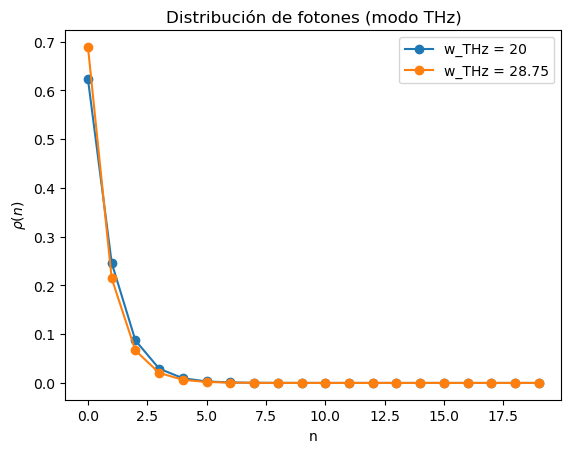

In [12]:
# vamos a tomar 2 valores de w_THz, y Delta_q = Delta_a = 0
w_THz_list = [20, 28.75]
Delta_q = 0
Delta_a = 0


rho_n_list = []

for w_b in w_THz_list:
    
    H = (Omega/2) * sx \
        + Delta_a * a_plus * a \
        + Delta_q * sz \
        + w_b * b_plus * b \
        + g * (a_plus * sm + a * sp) \
        + chi * (sz + 1) * (b_plus + b)

    rho_ss = steadystate(H, Dissipators)

    # Traza parcial en modo THz
    rho_mode = ptrace(rho_ss, 2)   

    #rho_ n  <n|rho|n>  que tamb se puede calcualr así (creo)
    rho_n = [expect(fock_dm(Nb, n), rho_mode) for n in range(Nb)]
    rho_n_list.append(rho_n)



# Gráfica
n_vals = np.arange(Nb)
plt.figure()

for i, rho_n in enumerate(rho_n_list):
    plt.plot(n_vals, rho_n, marker='o', label=f'w_THz = {w_THz_list[i]}')

plt.xlabel('n')
plt.ylabel(r'$\rho(n)$')
plt.title('Distribución de fotones (modo THz)')
plt.legend()

plt.show()